In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

import time

In [69]:
#convert MINIST image to tensor of 4D (images, height, width, collour)
transform = transforms.Compose([transforms.ToTensor()])

In [70]:
#train data
train_data = datasets.MNIST(root='./cnn_data', train= True, download=True, transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./cnn_data\MNIST\raw\train-images-idx3-ubyte.gz to ./cnn_data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./cnn_data\MNIST\raw\train-labels-idx1-ubyte.gz to ./cnn_data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./cnn_data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./cnn_data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./cnn_data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./cnn_data\MNIST\raw



In [71]:
#test data
test_data = datasets.MNIST(root='./cnn_data', train= False, download=True, transform=transform)

In [72]:
train_data, test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: ./cnn_data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
            ),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: ./cnn_data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
            ))

In [73]:
#create a small batch size for imaes 
train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=10, shuffle=True)

In [74]:
#define CNN model
#2-conv
conv1 = nn.Conv2d(1,6,3,1)
conv2 = nn.Conv2d(6,16,3,1)

In [75]:
for i,(x_train, y_train) in enumerate(train_data):
    break

x_train.shape

torch.Size([1, 28, 28])

In [76]:
x = x_train.view(1,1,28,28)
x = F.relu(conv1(x))
#single image , 6- filters
x.shape

torch.Size([1, 6, 26, 26])

In [77]:
#kernal - 2 , stride of 2
x = F.max_pool2d(x,2,2)
x.shape

torch.Size([1, 6, 13, 13])

In [78]:
x = F.relu(conv2(x))
x.shape

torch.Size([1, 16, 11, 11])

In [79]:
x = F.max_pool2d(x,2,2)
x.shape

torch.Size([1, 16, 5, 5])

In [80]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)
        #filly connected layer
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x,2,2)
        
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x,2,2)
        
        #flatten
        x = x.view(-1, 16*5*5)
        
        #fully connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return F.log_softmax(x, dim=1)

In [81]:
#crete intance
torch.manual_seed(42)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [82]:
#loss function 
critation = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [83]:
start_time = time.time()

#create variables to tracks thingd
epoches = 3
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# for loop of epoches

for i in range(epoches):
    train_corr = 0
    test_crr = 0
    #Train
    for b,(x_train, y_train) in enumerate(train_loader):
        b+=1 #start batch from 1
        y_pred = model(x_train)
        loss = critation(y_pred, y_train)
        
        prediction = torch.max(y_pred.data, 1)[1]
        batch_correct = (prediction == y_train).sum()
        train_corr += batch_correct
        
        #update parameter
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        #print
        if b%600 == 0:
            print(f"epoch : {i} batch:{b} loss: {loss.item()}")
    
    train_losses.append(loss)
    train_correct.append(train_corr)
        
    #test
    with torch.no_grad():
        
        for b,(x_test,y_test) in enumerate(test_loader):
            y_val = model(x_test)
            predicted = torch.max(y_val.data, 1)[1]
            test_crr += (predicted == y_test).sum()
    
    loss = critation(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(test_correct)
    

current_time = time.time()
total_time = current_time - start_time
print(f"training Tule : {total_time/60} minuts")

epoch : 0 batch:600 loss: 0.03516487032175064
epoch : 0 batch:1200 loss: 0.09470237791538239
epoch : 0 batch:1800 loss: 0.26980969309806824
epoch : 0 batch:2400 loss: 0.031088342890143394
epoch : 0 batch:3000 loss: 0.00800354965031147
epoch : 0 batch:3600 loss: 0.0015454263193532825
epoch : 0 batch:4200 loss: 0.5087021589279175
epoch : 0 batch:4800 loss: 0.028084253892302513
epoch : 0 batch:5400 loss: 0.0054753185249865055
epoch : 0 batch:6000 loss: 0.07390753924846649
epoch : 1 batch:600 loss: 0.00278500490821898
epoch : 1 batch:1200 loss: 0.01127017755061388
epoch : 1 batch:1800 loss: 0.09075005352497101
epoch : 1 batch:2400 loss: 0.05701100081205368
epoch : 1 batch:3000 loss: 0.004432931542396545
epoch : 1 batch:3600 loss: 0.03424118086695671
epoch : 1 batch:4200 loss: 0.008403787389397621
epoch : 1 batch:4800 loss: 0.000462119176518172
epoch : 1 batch:5400 loss: 0.08369633555412292
epoch : 1 batch:6000 loss: 0.011113042011857033
epoch : 2 batch:600 loss: 0.10677160322666168
epoch :

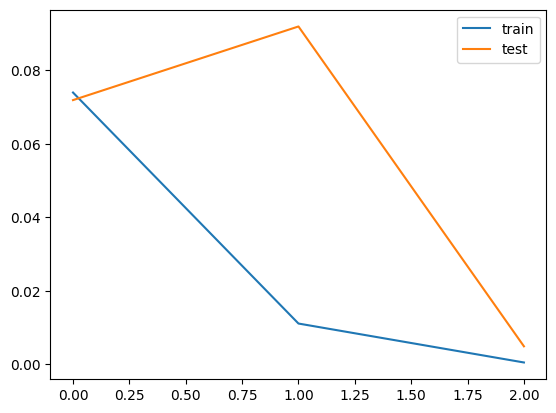

In [84]:
train_loss = [t1.item() for t1 in train_losses]
plt.plot(train_loss, label="train")
plt.plot(test_losses, label="test")
plt.legend()
plt.show()

In [67]:
test_load_everything = DataLoader(test_data, batch_size=10000, shuffle=False)

In [86]:
with torch.no_grad():
    correct = 0
    for x_tesst, y_test in test_load_everything:
        y_val = model(x_tesst)
        predicted = torch.max(y_val, 1)[1]
        correct += (predicted == y_test).sum()

In [87]:
correct.item()/len(test_data)*100

98.64

In [92]:
test_img = test_data[4000][0]

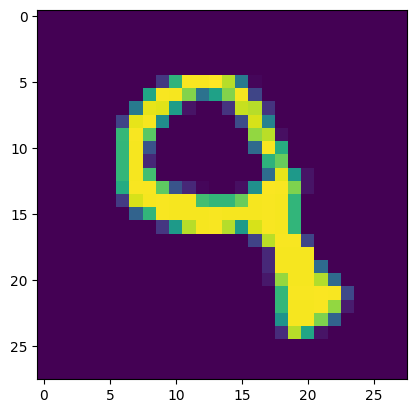

In [93]:
plt.imshow(test_img.reshape(28,28))

In [96]:
#pass image to model
model.eval()
with torch.no_grad():
    new_pred =  model(test_img.view(1,1,28,28))
    
new_pred, new_pred.argmax()

(tensor([[-2.2250e+01, -1.9921e+01, -1.6131e+01, -1.4933e+01, -7.3292e+00,
          -1.3377e+01, -2.1311e+01, -1.7151e+01, -8.6249e+00, -8.3805e-04]]),
 tensor(9))